Supplementary Code S6. Leakage audit & driver diagnostics for post-MI biomarker models (FULL / CLINICAL / BIOMARKERS)

Purpose.
This notebook provides a leakage-focused diagnostic audit of the winner models identified in Supplementary Code S2 and summarized in S5, with the explicit goal of explaining unusually high internal discrimination (e.g., ROC AUC approaching 1.0) and identifying whether such performance may plausibly reflect hidden information leakage, outcome proxies, or timing/definition confounds. The notebook operationalizes a reviewer-facing sensitivity analysis: exceptionally high performance is treated as a diagnostic signal rather than evidence of clinical readiness.

Scope and relationship to prior scripts.

S2 establishes nested cross-validation benchmarking and selects winner models per feature-set variant.

S5 summarizes performance–complexity trade-offs using governed feature sets and OOF artifacts.

S6 is a post-hoc audit notebook that reuses the same governed predictor sets and fixed winner hyperparameters to quantify which predictors drive performance and to evaluate whether performance is robust to removal of suspect predictors.

Key principles (journal-ready).

Uses fixed winner configurations (model class + hyperparameters) derived from S2, without re-tuning.

Uses outer-fold OOF evaluation as the default diagnostic estimator; S6 does not create a new “best model”.

Treats feature sets as governed inputs (FULL / CLINICAL / BIOMARKERS) and reports the effective number of usable predictors after coercion and removal of all-missing/constant features (to prevent silent preprocessing artifacts).

Emphasizes interpretability as stability and driver dependence, rather than mechanistic explanation.

Methods implemented in S6

For each feature-set variant (FULL, CLINICAL, BIOMARKERS), the notebook performs:

Sanity check vs S2 artifacts (consistency audit).
Recomputes OOF ROC AUC for each variant using the fixed winner model + fixed hyperparameters and verifies agreement (within tolerance) with the S2 summary metric. This step is designed to detect mismatches due to target definition, cohort filtering, or feature encoding differences.

Leakage name-pattern screen (heuristic).
Searches predictor names for patterns suggestive of post-outcome availability (e.g., discharge, death, rehospitalization, follow-up, length of stay). This is a conservative, reviewer-facing heuristic to flag potential timing confounds.

Univariate driver screen (fold-aware).
Computes univariate, cross-validated ROC AUC per feature (logistic baseline) to identify predictors that alone provide unexpectedly strong discrimination (potential proxy variables).

Feature–outcome association screen (audit only).
Computes Spearman correlation with the outcome only for non-constant features as an exploratory indicator of strong outcome association (not used for feature selection).

Outer-fold permutation importance (leakage-safe).
Estimates permutation importance using outer test folds only, yielding fold-aggregated “AUC drop” importance values that are less vulnerable to optimistic bias.

EARLY-features sensitivity (CLINICAL_EARLY).
Constructs an “EARLY” subset by excluding variables likely to be downstream or follow-up related and reports OOF ROC AUC as a sensitivity analysis. This tests whether performance persists under conservative, plausibly pre-event availability assumptions.

Note: S6 is intentionally diagnostic. It does not claim causal interpretation of feature importance, and it does not propose a deployable model. The outputs serve to justify methodological conclusions and to support transparent reviewer communication about leakage risk.

Inputs (from S2/S5 workflow)

Required:

processed_dataset.csv (from S1 preprocessing output)

winner_model_by_variant.csv (from S2; includes winner model + S2 performance summary used as reference)

nestedcv_bestparams_all_variants.csv (from S2; best hyperparameters per variant/model)

features_used_FULL.csv, features_used_CLINICAL.csv, features_used_BIOMARKERS.csv (final governed feature lists used for variant matrices)

Optional:

audit_nonnumeric_features.csv (from S1; used to exclude non-numeric predictors if available)

Outputs (publication- and audit-ready)

Core tables (per variant):

S6_<VARIANT>_univariate_auc.csv — fold-aware univariate ROC AUC ranking

S6_<VARIANT>_spearman_assoc.csv — Spearman feature–outcome association (audit only)

S6_<VARIANT>_perm_importance_outer.csv — outer-fold permutation importance (“AUC drop”)

S6_<VARIANT>_leakage_name_hits.csv — heuristic name-based leakage flags

S6_<VARIANT>_binary_recode_audit.csv (if applicable) — audit of text→binary recoding applied to predictors

S6_<VARIANT>_dropped_empty_or_constant_FINAL.csv — predictors removed due to all-missing or constant values (prevents silent preprocessing artifacts)

Cross-variant summaries:

S6_variant_matrix_diagnostics_FINAL.csv — counts of governed, recoded, dropped, and effective predictors per variant

S6_sanity_check_vs_S2_FINAL.csv — S6 OOF ROC AUC vs S2 reference (consistency check)

S6_cross_variant_summary.csv — consolidated driver metrics across variants

S6_run_log.json — fully auditable record of inputs, configuration, and outputs

S6_auc_diagnostic.png — compact visual summary of diagnostic OOF AUC across variants

## Setup, paths, output directories

In [1]:
from __future__ import annotations

import json
import re
from collections import Counter
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ROOT = Path("/content") if Path("/content").exists() else Path.cwd()

OUT_DIR = ROOT / "results" / "S6_leakage_audit"
TAB_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
LOG_DIR = OUT_DIR / "logs"
for d in (TAB_DIR, FIG_DIR, LOG_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("Writing outputs to:", OUT_DIR.resolve())


ROOT: /content
Writing outputs to: /content/results/S6_leakage_audit


## Finder files

In [2]:
SEARCH_ROOTS = [
    ROOT,
    ROOT / "results",
    ROOT / "results" / "S1_preprocessing",
    ROOT / "results" / "S2_nestedcv",
    ROOT / "results" / "S3_benchmark_summary",
    ROOT / "results" / "S4_calibration_thresholds",
    ROOT / "results" / "S5_tradeoff",
    Path("/mnt/data"),
    ROOT / "drive",
    ROOT / "drive" / "MyDrive",
]

def find_file(filename: str, roots: list[Path]) -> Path:
    for r in roots:
        p = r / filename
        if p.exists():
            return p
    for r in roots:
        if r.exists():
            hits = list(r.rglob(filename))
            if hits:
                hits = sorted(hits, key=lambda x: len(str(x)))
                return hits[0]
    raise FileNotFoundError(
        f"Missing required file: {filename}\nSearched in:\n - " + "\n - ".join(map(str, roots))
    )

def read_csv_required(name: str) -> tuple[pd.DataFrame, Path]:
    p = find_file(name, SEARCH_ROOTS)
    df = pd.read_csv(p)
    print(f"Loaded: {p} | shape={df.shape}")
    return df, p

def load_feature_list(path: Path) -> list[str]:
    fdf = pd.read_csv(path)
    fdf.columns = [c.strip() for c in fdf.columns]
    for col in ["feature", "features", "feature_name", "column", "variable", "var", "name"]:
        if col in fdf.columns:
            feats = fdf[col].astype(str).str.strip().tolist()
            return [f for f in feats if f and f.lower() != "nan"]
    feats = fdf.iloc[:, 0].astype(str).str.strip().tolist()
    return [f for f in feats if f and f.lower() != "nan"]


## Loading artifacts

In [3]:
df, path_processed = read_csv_required("processed_dataset.csv")
winner_df, path_winners = read_csv_required("winner_model_by_variant.csv")
bestparams_df, path_best = read_csv_required("nestedcv_bestparams_all_variants.csv")

p_full = find_file("features_used_FULL.csv", SEARCH_ROOTS)
p_clin = find_file("features_used_CLINICAL.csv", SEARCH_ROOTS)
p_bio  = find_file("features_used_BIOMARKERS.csv", SEARCH_ROOTS)

features_used = {
    "FULL": load_feature_list(p_full),
    "CLINICAL": load_feature_list(p_clin),
    "BIOMARKERS": load_feature_list(p_bio),
}

print("Governed feature counts:")
for v in ["FULL", "CLINICAL", "BIOMARKERS"]:
    print(f"  {v}: {len(features_used[v])}")

pd.DataFrame({
    "variant": ["FULL", "CLINICAL", "BIOMARKERS"],
    "n_features_governed": [len(features_used["FULL"]), len(features_used["CLINICAL"]), len(features_used["BIOMARKERS"])],
}).to_csv(TAB_DIR / "S6_governed_feature_counts.csv", index=False)
print("Saved:", TAB_DIR / "S6_governed_feature_counts.csv")


Loaded: /content/processed_dataset.csv | shape=(152, 117)
Loaded: /content/winner_model_by_variant.csv | shape=(3, 8)
Loaded: /content/nestedcv_bestparams_all_variants.csv | shape=(60, 5)
Governed feature counts:
  FULL: 69
  CLINICAL: 58
  BIOMARKERS: 10
Saved: /content/results/S6_leakage_audit/tables/S6_governed_feature_counts.csv


## Target + label validation

In [4]:
TARGET_COL = "typ_zawalu"
if TARGET_COL not in df.columns:
    raise ValueError(f"TARGET_COL='{TARGET_COL}' not found in processed_dataset.csv")

labels = df[TARGET_COL].astype(str).str.strip()
allowed = {"STEMI", "NSTEMI"}

df = df.loc[labels.isin(allowed)].copy()
y = (df[TARGET_COL].astype(str).str.strip() == "STEMI").astype(int).values

print("TARGET_COL:", TARGET_COL)
print("Task: STEMI vs NSTEMI (positive=STEMI)")
print("Class counts:\n", pd.Series(y).value_counts())
print("Positive rate:", float(np.mean(y)))


for k in features_used:
    features_used[k] = [f for f in features_used[k] if f != TARGET_COL]


TARGET_COL: typ_zawalu
Task: STEMI vs NSTEMI (positive=STEMI)
Class counts:
 0    32
1    25
Name: count, dtype: int64
Positive rate: 0.43859649122807015


## Audit nonnumeric

In [5]:
NONNUMERIC_FEATURES = set()
path_audit = None
try:
    audit_df, path_audit = read_csv_required("audit_nonnumeric_features.csv")
    cand = ["feature","feature_name","column","variable","var","name"]
    col = next((c for c in cand if c in audit_df.columns), None)
    if col is None:
        col = audit_df.columns[0]
    NONNUMERIC_FEATURES = set(audit_df[col].astype(str).tolist())
    print("Loaded NONNUMERIC_FEATURES:", len(NONNUMERIC_FEATURES))
except FileNotFoundError:
    print("NOTE: audit_nonnumeric_features.csv not found (OK).")

df_coerced = df.copy()


NOTE: audit_nonnumeric_features.csv not found (OK).


## Winner parameters: parsing JSON with best_params + make_pipeline

In [6]:
WINNER_MODELS = {row["variant"]: row["model"] for _, row in winner_df.iterrows()}

def aggregate_best_params_json(variant: str, model_key: str) -> dict:

    dfp = bestparams_df[(bestparams_df["variant"] == variant) & (bestparams_df["model"] == model_key)].copy()
    if dfp.empty:
        print(f"WARNING: No bestparams rows for (variant={variant}, model={model_key}). Using empty params.")
        return {}

    if "best_params" not in dfp.columns:
        raise ValueError("nestedcv_bestparams_all_variants.csv must contain column 'best_params' (JSON string).")

    params_list = []
    for s in dfp["best_params"].dropna().tolist():
        try:
            params_list.append(json.loads(s))
        except Exception as e:
            raise ValueError(f"Failed to parse best_params JSON: {s}") from e

    if not params_list:
        return {}

    all_keys = set().union(*params_list)
    out = {}
    for k in all_keys:
        vals = [p.get(k) for p in params_list if k in p]
        cnt = Counter([json.dumps(v, sort_keys=True) for v in vals])
        mode_str = cnt.most_common(1)[0][0]
        out[k] = json.loads(mode_str)
    return out

BEST_PARAMS = {v: aggregate_best_params_json(v, WINNER_MODELS[v]) for v in WINNER_MODELS.keys()}

print("Winner models:", WINNER_MODELS)
print("Best params (aggregated):", BEST_PARAMS)

def make_pipeline(variant_name: str) -> Pipeline:
    model_key = WINNER_MODELS[variant_name]
    params = BEST_PARAMS.get(variant_name, {}).copy()
    params_clean = {k.replace("clf__", ""): v for k, v in params.items()}

    if model_key in ["LR", "LogReg", "LOGREG", "LOGISTIC"]:
        clf = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, **params_clean)
        use_scaler = True
    elif model_key == "RF":
        clf = RandomForestClassifier(random_state=RANDOM_STATE, **params_clean)
        use_scaler = False
    elif model_key in ["SVM", "LinearSVM"]:
        params_clean["probability"] = True
        clf = SVC(random_state=RANDOM_STATE, **params_clean)
        use_scaler = True
    elif model_key == "KNN":
        clf = KNeighborsClassifier(**params_clean)
        use_scaler = True
    elif model_key == "NB":
        clf = GaussianNB(**params_clean)
        use_scaler = False
    else:
        raise ValueError(f"Unsupported model key: {model_key}")

    steps = [("imputer", SimpleImputer(strategy="median"))]
    if use_scaler:
        steps.append(("scaler", StandardScaler()))
    preprocess = Pipeline(steps)

    return Pipeline([("preprocess", preprocess), ("clf", clf)])


Winner models: {'BIOMARKERS': 'RF', 'CLINICAL': 'RF', 'FULL': 'RF'}
Best params (aggregated): {'BIOMARKERS': {'clf__max_features': 'sqrt', 'clf__min_samples_split': 2, 'clf__max_depth': None, 'clf__min_samples_leaf': 1}, 'CLINICAL': {'clf__max_features': 'log2', 'clf__min_samples_split': 2, 'clf__max_depth': None, 'clf__min_samples_leaf': 4}, 'FULL': {'clf__max_features': 'sqrt', 'clf__min_samples_split': 2, 'clf__max_depth': None, 'clf__min_samples_leaf': 1}}


## Helper functions: remove_features, pipeline, params

In [7]:
def remove_features(X: np.ndarray, feature_names: np.ndarray, to_remove: list[str]) -> tuple[np.ndarray, np.ndarray]:
    keep = ~np.isin(feature_names, to_remove)
    return X[:, keep], feature_names[keep]

def _normalize_str_series(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .str.strip()
         .str.lower()
         .str.replace(",", ".", regex=False)
    )

YES_SET = {"yes","y","true","t","1","tak","on","present","positive","pos"}
NO_SET  = {"no","n","false","f","0","nie","off","absent","negative","neg"}

def _try_map_binary_object(col: pd.Series) -> tuple[pd.Series, bool, dict]:
    audit = {"unique_raw": None, "unique_norm": None, "unmapped_norm": None}

    if col.dropna().map(type).isin([bool]).any():
        mapped = col.map(lambda v: 1 if v is True else (0 if v is False else np.nan))
        return mapped.astype(float), True, {"mode": "bool", "unique_raw": sorted(col.dropna().unique().tolist())}

    norm = _normalize_str_series(col)
    uniq = sorted(norm.dropna().unique().tolist())
    audit["unique_raw"] = sorted(col.dropna().unique().tolist())[:50]
    audit["unique_norm"] = uniq[:50]

    if len(uniq) == 0:
        return pd.Series(np.nan, index=col.index), False, audit

    if len(set(uniq)) <= 2 and all(u in (YES_SET | NO_SET) for u in uniq):
        def map_one(v):
            if pd.isna(v):
                return np.nan
            vv = str(v).strip().lower()
            if vv in YES_SET: return 1
            if vv in NO_SET:  return 0
            return np.nan
        mapped = norm.map(map_one).astype(float)
        unmapped = sorted(set(uniq) - (YES_SET | NO_SET))
        audit["unmapped_norm"] = unmapped
        return mapped, True, {"mode": "yes_no", **audit}

    return col, False, audit

def oof_auc_fixed_params(pipe: Pipeline, X: np.ndarray, y: np.ndarray, cv) -> tuple[np.ndarray, dict]:
    oof_probs = np.zeros(len(y), dtype=float)
    fold_aucs = []
    for tr, te in cv.split(X, y):
        pipe.fit(X[tr], y[tr])
        probs = pipe.predict_proba(X[te])[:, 1]
        oof_probs[te] = probs
        fold_aucs.append(roc_auc_score(y[te], probs))
    metrics = {
        "auc_oof": float(roc_auc_score(y, oof_probs)),
        "auc_outer_mean": float(np.mean(fold_aucs)),
        "auc_outer_sd": float(np.std(fold_aucs, ddof=1)),
    }
    return oof_probs, metrics


## X matrix construction (final governed) + all-NaN / high-NaN / constant diagnostics

In [8]:
def build_matrix_from_governed_features(
    df_in: pd.DataFrame,
    feats: list[str],
    variant_name: str,
    drop_all_nan: bool = True,
    drop_constant: bool = True,
) -> tuple[np.ndarray, np.ndarray, dict]:

    feats = [f for f in feats if f in df_in.columns and f != TARGET_COL]
    feats = [f for f in feats if f not in NONNUMERIC_FEATURES]
    Xdf = df_in[feats].copy()

    recode_audit = []
    for c in Xdf.columns:
        if Xdf[c].dtype == "object" or str(Xdf[c].dtype).startswith("bool"):
            mapped, ok, info = _try_map_binary_object(Xdf[c])
            if ok:
                Xdf[c] = mapped
                recode_audit.append({"feature": c, **info})

    if recode_audit:
        pd.DataFrame(recode_audit).to_csv(TAB_DIR / f"S6_{variant_name}_binary_recode_audit.csv", index=False)
        print(f"{variant_name}: saved ->", TAB_DIR / f"S6_{variant_name}_binary_recode_audit.csv")

    for c in Xdf.columns:
        if Xdf[c].dtype == "object":
            Xdf[c] = _normalize_str_series(Xdf[c])
        Xdf[c] = pd.to_numeric(Xdf[c], errors="coerce")

    nan_rate = Xdf.isna().mean()
    all_nan = nan_rate[nan_rate == 1.0].index.tolist()

    nunique = Xdf.nunique(dropna=True)
    constant = nunique[nunique <= 1].index.tolist()

    dropped = []
    if drop_all_nan and all_nan:
        dropped += all_nan
    if drop_constant and constant:
        dropped += constant
    dropped = sorted(set(dropped))

    if all_nan:
        pd.DataFrame({"feature": all_nan}).to_csv(TAB_DIR / f"S6_{variant_name}_all_nan_after_coercion_FINAL.csv", index=False)
    if constant:
        pd.DataFrame({"feature": constant}).to_csv(TAB_DIR / f"S6_{variant_name}_constant_features_FINAL.csv", index=False)
    if dropped:
        pd.DataFrame({"feature": dropped}).to_csv(TAB_DIR / f"S6_{variant_name}_dropped_empty_or_constant_FINAL.csv", index=False)
        Xdf = Xdf.drop(columns=dropped)

    diag = {
        "n_governed_present": int(len(feats)),
        "n_binary_recoded": int(len(recode_audit)),
        "n_dropped_empty_or_constant": int(len(dropped)),
        "n_used_matrix": int(Xdf.shape[1]),
        "n_all_nan_after_coercion": int(len(all_nan)),
        "n_constant_le_1_unique": int(len(constant)),
    }
    return Xdf.values, np.array(Xdf.columns.tolist()), diag

variants_cfg = {}
diag_rows = []
for v in ["FULL", "CLINICAL", "BIOMARKERS"]:
    Xv, fnames, diag = build_matrix_from_governed_features(df_coerced, features_used[v], v)
    variants_cfg[v] = {"X": Xv, "features": fnames, "diag": diag}
    diag_rows.append({"variant": v, **diag})

diag_df = pd.DataFrame(diag_rows).sort_values("variant").reset_index(drop=True)
diag_df.to_csv(TAB_DIR / "S6_variant_matrix_diagnostics_FINAL.csv", index=False)
print("Saved:", TAB_DIR / "S6_variant_matrix_diagnostics_FINAL.csv")
display(diag_df)


FULL: saved -> /content/results/S6_leakage_audit/tables/S6_FULL_binary_recode_audit.csv
CLINICAL: saved -> /content/results/S6_leakage_audit/tables/S6_CLINICAL_binary_recode_audit.csv
Saved: /content/results/S6_leakage_audit/tables/S6_variant_matrix_diagnostics_FINAL.csv


,variant,n_governed_present,n_binary_recoded,n_dropped_empty_or_constant,n_used_matrix,n_all_nan_after_coercion,n_constant_le_1_unique
0,BIOMARKERS,10,0,0,10,0,0
1,CLINICAL,58,21,15,43,15,15
2,FULL,69,21,15,54,15,15


## Sanity-check vs S2

In [9]:
TOL_AUC = 0.06

rows = []
for v in ["FULL", "CLINICAL", "BIOMARKERS"]:
    pipe = make_pipeline(v)
    _, m = oof_auc_fixed_params(pipe, variants_cfg[v]["X"], y, cv_outer)

    ref_row = winner_df[winner_df["variant"] == v].iloc[0]
    ref_auc = float(ref_row["roc_auc_mean"])

    rows.append({
        "variant": v,
        "auc_oof_diagnostic": m["auc_oof"],
        "ref_auc_s2_mean": ref_auc,
        "abs_auc_diff": abs(m["auc_oof"] - ref_auc),
        "pass_auc_tol": abs(m["auc_oof"] - ref_auc) <= TOL_AUC,
        "n_features_effective_used": int(len(variants_cfg[v]["features"])),
        "n_binary_recoded": int(variants_cfg[v]["diag"]["n_binary_recoded"]),
        "n_dropped_empty_or_constant": int(variants_cfg[v]["diag"]["n_dropped_empty_or_constant"]),
        "winner_model": WINNER_MODELS.get(v),
    })

sanity_df = pd.DataFrame(rows).sort_values("variant").reset_index(drop=True)
sanity_path = TAB_DIR / "S6_sanity_check_vs_S2_FINAL.csv"
sanity_df.to_csv(sanity_path, index=False)
print("Saved:", sanity_path)
display(sanity_df)

failed = sanity_df.loc[~sanity_df["pass_auc_tol"], "variant"].tolist()
if failed:
    print("\n SANITY CHECK FAILED:", failed, "(Notebook continues; diagnostics below will run.)")
else:
    print("\n SANITY CHECK PASSED for all variants.")


Saved: /content/results/S6_leakage_audit/tables/S6_sanity_check_vs_S2_FINAL.csv


,variant,auc_oof_diagnostic,ref_auc_s2_mean,abs_auc_diff,pass_auc_tol,n_features_effective_used,n_binary_recoded,n_dropped_empty_or_constant,winner_model
0,BIOMARKERS,0.914375,0.949524,0.035149,True,10,0,0,RF
1,CLINICAL,0.622500,0.594286,0.028214,True,43,21,15,RF
2,FULL,1.000000,0.994286,0.005714,True,54,21,15,RF



 SANITY CHECK PASSED for all variants.


## Diagnostics: leakage keyword scan

In [10]:
LEAKAGE_NAME_PATTERNS = [
    r"wypis", r"discharge", r"los\b", r"length[_ ]of[_ ]stay", r"days[_ ]in", r"icu",
    r"zgon", r"death", r"mortal", r"event", r"endpoint", r"outcome",
    r"readmi", r"rehosp", r"re[-_ ]?hospital",
    r"follow", r"kontrol", r"control", r"time[_ ]to", r"czas[_ ]do",
    r"ventil", r"intub"
]
rx = re.compile("|".join(LEAKAGE_NAME_PATTERNS), flags=re.IGNORECASE)

for v in ["FULL", "CLINICAL", "BIOMARKERS"]:
    feats = variants_cfg[v]["features"]
    hits = [f for f in feats if rx.search(str(f))]
    out_path = TAB_DIR / f"S6_{v}_leakage_name_hits.csv"
    pd.DataFrame({"feature": hits}).to_csv(out_path, index=False)
    print(f"{v}: leakage-name hits = {len(hits)} | saved: {out_path}")


FULL: leakage-name hits = 0 | saved: /content/results/S6_leakage_audit/tables/S6_FULL_leakage_name_hits.csv
CLINICAL: leakage-name hits = 0 | saved: /content/results/S6_leakage_audit/tables/S6_CLINICAL_leakage_name_hits.csv
BIOMARKERS: leakage-name hits = 0 | saved: /content/results/S6_leakage_audit/tables/S6_BIOMARKERS_leakage_name_hits.csv


## CLINICAL_EARLY

In [11]:
LATE_NAME_PATTERNS = [
    r"wypis", r"discharge", r"po[_ ]", r"after", r"follow", r"kontrol", r"control",
    r"zgon", r"death", r"mortal", r"event", r"endpoint", r"outcome",
    r"readmi", r"rehosp", r"re[-_ ]?hospital", r"czas[_ ]do", r"time[_ ]to",
    r"los\b", r"length[_ ]of[_ ]stay", r"days[_ ]in", r"icu", r"ventil", r"intub",
]
EARLY_NAME_HINTS = [r"baseline", r"admission", r"przyj", r"t0\b", r"day0", r"d0\b"]

late_rx = re.compile("|".join(LATE_NAME_PATTERNS), flags=re.IGNORECASE)
hint_rx = re.compile("|".join(EARLY_NAME_HINTS), flags=re.IGNORECASE)

def auto_select_early(feats: np.ndarray) -> list[str]:
    early = [f for f in feats if not late_rx.search(str(f))]
    hinted = [f for f in early if hint_rx.search(str(f))]
    if len(hinted) >= 5:
        early = hinted
    return sorted(set(early))

early_list = auto_select_early(variants_cfg["CLINICAL"]["features"])
pd.DataFrame({"feature": early_list}).to_csv(TAB_DIR / "S6_CLINICAL_auto_early_features.csv", index=False)
print("Saved:", TAB_DIR / "S6_CLINICAL_auto_early_features.csv")

Xc = variants_cfg["CLINICAL"]["X"]
fc = variants_cfg["CLINICAL"]["features"]

to_remove = list(set(fc) - set(early_list))
Xc_early, fc_early = remove_features(Xc, fc, to_remove)

pipe = make_pipeline("CLINICAL")
_, m = oof_auc_fixed_params(pipe, Xc_early, y, cv_outer)

ref_auc = float(winner_df[winner_df["variant"] == "CLINICAL"].iloc[0]["roc_auc_mean"])
print("CLINICAL_EARLY AUC (diagnostic):", m["auc_oof"])
print("S2 CLINICAL ref AUC:", ref_auc)
print("Abs diff:", abs(m["auc_oof"] - ref_auc))

pd.DataFrame({"feature": fc_early}).to_csv(TAB_DIR / "S6_CLINICAL_EARLY_features.csv", index=False)
print("Saved:", TAB_DIR / "S6_CLINICAL_EARLY_features.csv")


Saved: /content/results/S6_leakage_audit/tables/S6_CLINICAL_auto_early_features.csv
CLINICAL_EARLY AUC (diagnostic): 0.54375
S2 CLINICAL ref AUC: 0.5942857142857143
Abs diff: 0.05053571428571435
Saved: /content/results/S6_leakage_audit/tables/S6_CLINICAL_EARLY_features.csv


## Audyt: univariate / spearman / permutation (outer-fold) + summary

In [12]:
def single_feature_auc_cv(X: np.ndarray, y: np.ndarray, feature_names: np.ndarray, cv) -> pd.DataFrame:
    aucs = []
    for j in range(len(feature_names)):
        xj = X[:, [j]]
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
        ])
        oof = np.zeros(len(y), dtype=float)
        for tr, te in cv.split(xj, y):
            pipe.fit(xj[tr], y[tr])
            oof[te] = pipe.predict_proba(xj[te])[:, 1]
        aucs.append(roc_auc_score(y, oof))
    return (pd.DataFrame({"feature": feature_names, "auc_univariate": aucs})
              .sort_values("auc_univariate", ascending=False)
              .reset_index(drop=True))

def feature_outcome_association(X: np.ndarray, y: np.ndarray, feature_names: np.ndarray) -> pd.DataFrame:
    assoc = []
    y_bin = y.astype(int)
    for j, fname in enumerate(feature_names):
        xj = X[:, j]
        if np.nanstd(xj) == 0 or pd.Series(xj).nunique(dropna=True) <= 1:
            rho = np.nan
        else:
            rho = pd.Series(xj).corr(pd.Series(y_bin), method="spearman")
        assoc.append((fname, rho))
    out = pd.DataFrame(assoc, columns=["feature","spearman_rho_y"])
    out["abs_rho"] = out["spearman_rho_y"].abs()
    return out.sort_values("abs_rho", ascending=False).drop(columns=["abs_rho"]).reset_index(drop=True)

def permutation_importance_outer(pipe: Pipeline, X: np.ndarray, y: np.ndarray, feature_names: np.ndarray, cv) -> pd.DataFrame:
    imp = np.zeros(X.shape[1], dtype=float)
    for tr, te in cv.split(X, y):
        pipe.fit(X[tr], y[tr])
        res = permutation_importance(
            pipe, X[te], y[te],
            scoring="roc_auc",
            n_repeats=30,
            random_state=RANDOM_STATE
        )
        imp += res.importances_mean
    imp /= cv.get_n_splits()
    return (pd.DataFrame({"feature": feature_names, "perm_auc_drop": imp})
              .sort_values("perm_auc_drop", ascending=False)
              .reset_index(drop=True))

summary_rows = []
for v in ["FULL", "CLINICAL", "BIOMARKERS"]:
    Xv = variants_cfg[v]["X"]
    feats = variants_cfg[v]["features"]

    pipe = make_pipeline(v)
    _, m = oof_auc_fixed_params(pipe, Xv, y, cv_outer)

    df_uni = single_feature_auc_cv(Xv, y, feats, cv_outer)
    df_assoc = feature_outcome_association(Xv, y, feats)
    df_perm = permutation_importance_outer(pipe, Xv, y, feats, cv_outer)

    df_uni.to_csv(TAB_DIR / f"S6_{v}_univariate_auc.csv", index=False)
    df_assoc.to_csv(TAB_DIR / f"S6_{v}_spearman_assoc.csv", index=False)
    df_perm.to_csv(TAB_DIR / f"S6_{v}_perm_importance_outer.csv", index=False)

    summary_rows.append({
        "variant": v,
        "winner_model": WINNER_MODELS.get(v),
        "n_features_effective": int(len(feats)),
        "auc_oof_diagnostic": float(m["auc_oof"]),
        "top_univariate_auc": float(df_uni["auc_univariate"].iloc[0]) if len(df_uni) else np.nan,
        "top_perm_auc_drop": float(df_perm["perm_auc_drop"].iloc[0]) if len(df_perm) else np.nan,
    })

df_summary = pd.DataFrame(summary_rows).sort_values("variant").reset_index(drop=True)
summary_path = TAB_DIR / "S6_cross_variant_summary.csv"
df_summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)
display(df_summary)


Saved: /content/results/S6_leakage_audit/tables/S6_cross_variant_summary.csv


,variant,winner_model,n_features_effective,auc_oof_diagnostic,top_univariate_auc,top_perm_auc_drop
0,BIOMARKERS,RF,10,0.914375,0.81750,0.285683
1,CLINICAL,RF,43,0.622500,0.66625,0.004730
2,FULL,RF,54,1.000000,0.98500,0.193111


### Interpretation note — univariate AUC screening is a *leakage diagnostic*, not a feature-selection step

This section computes **single-feature (univariate) cross-validated AUC** and related association diagnostics to *flag predictors that behave like outcome proxies* (e.g., temporally late variables or downstream clinical process indicators).

**How to read the results:**
- Very high univariate AUC (especially values approaching 1.0) is treated as an **intended diagnostic finding** indicating that the dataset may contain **leaky / downstream-coupled features**.
- These flags are used to support the *feature-governance audit* (keyword patterns, provenance checks, and plausibility review), **not** to optimize model performance or to justify clinical deployment.

In particular, high univariate AUC in the **FULL** variant is expected in this proof-of-concept workflow and should be interpreted as a warning signal consistent with the manuscript's leakage-aware framework (Section 5).


## Figure + run log (audit trail)

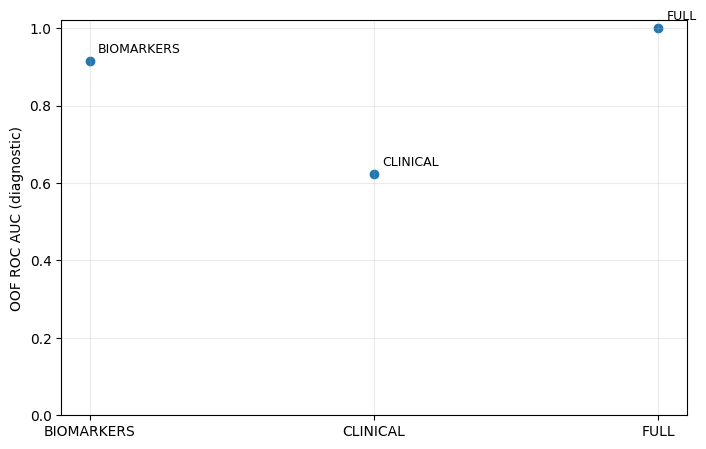

Saved: /content/results/S6_leakage_audit/figures/S6_auc_diagnostic.png
Saved: /content/results/S6_leakage_audit/logs/S6_run_log.json

DONE. Outputs at: /content/results/S6_leakage_audit


/tmp/ipython-input-4278074908.py:17: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow().isoformat() + "Z",


In [13]:
plt.figure(figsize=(7.2, 4.6))
x = np.arange(len(df_summary))
plt.scatter(x, df_summary["auc_oof_diagnostic"])
for i, r in df_summary.iterrows():
    plt.annotate(str(r["variant"]), (i, r["auc_oof_diagnostic"]), textcoords="offset points", xytext=(6,6), fontsize=9)
plt.xticks(x, df_summary["variant"].tolist())
plt.ylim(0.0, 1.02)
plt.grid(True, alpha=0.25)
plt.ylabel("OOF ROC AUC (diagnostic)")
fig_path = FIG_DIR / "S6_auc_diagnostic.png"
plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()
print("Saved:", fig_path)

run_log = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "random_state": RANDOM_STATE,
    "cv_outer": {"type":"StratifiedKFold","n_splits":5,"shuffle":True,"random_state":RANDOM_STATE},
    "inputs": {
        "processed_dataset.csv": str(path_processed),
        "winner_model_by_variant.csv": str(path_winners),
        "nestedcv_bestparams_all_variants.csv": str(path_best),
        "features_used_FULL.csv": str(p_full),
        "features_used_CLINICAL.csv": str(p_clin),
        "features_used_BIOMARKERS.csv": str(p_bio),
        "audit_nonnumeric_features.csv": str(path_audit) if path_audit else None,
    },
    "target": {
        "TARGET_COL": TARGET_COL,
        "task": "STEMI vs NSTEMI (positive=STEMI)",
        "n_samples": int(len(y)),
        "positive_rate": float(np.mean(y)),
    },
    "notes": [
        "S6 is a diagnostic leakage/sensitivity notebook using fixed winner hyperparameters from S2.",
        "Hyperparameters are parsed from best_params JSON in nestedcv_bestparams_all_variants.csv.",
        "Binary text predictors are mapped to 0/1; all-NaN and constant predictors are removed before sklearn."
    ],
    "outputs": {
        "tables_dir": str(TAB_DIR),
        "figures_dir": str(FIG_DIR),
        "logs_dir": str(LOG_DIR),
        "sanity_csv": str(sanity_path),
        "summary_csv": str(summary_path),
        "figure": str(fig_path),
    }
}

log_path = LOG_DIR / "S6_run_log.json"
log_path.write_text(json.dumps(run_log, indent=2), encoding="utf-8")
print("Saved:", log_path)

print("\nDONE. Outputs at:", OUT_DIR.resolve())